# 8. Cohort Visuals
In this notebook, we generate visuals of the results from the cohort study only sub-analysis. This assumes that the cohort study-specific logistic regression model has already been run.

In [1]:
library(tidyverse)
library(ggplot2)
library(rstan)
library(Hmisc)
library(forestplot)
library(readxl)
theme_set(theme_bw())
options(repr.matrix.max.rows = 100) 
options(pillar.print_max = 50) 
options(OutDec = "·")
save_plot = function(curr_plot, filepath, width, height, units, res, type = "png"){
    if(type == "png"){
        png(filepath, width = width, height = height, units = units, res = res)
    }else if(type == "eps"){
        #Defaults to inches as units
        postscript(filepath, width = width, height = height)
    }else{
        pdf(filepath, width = width, height = height)
    }
    print(curr_plot)
    dev.off()
}

save_plot_all_formats = function(curr_plot, dir_path, filename, width, height, units, res){
    png_path = file.path(dir_path, "png", paste0(filename, ".png"))
    eps_path = file.path(dir_path, "eps", paste0(filename, ".eps"))
    pdf_path = file.path(dir_path, "pdf", paste0(filename, ".pdf"))

    save_plot(curr_plot, png_path, width, height, units, res, type = "png")
    save_plot(curr_plot, eps_path, width, height, units, res, type = "eps")
    save_plot(curr_plot, pdf_path, width, height, units, res, type = "pdf")
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Loading required package: StanHeaders

rstan version 2.32.7 (Stan version 2.32.2)

For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Attac

## Reading Input

In [2]:
#Read in the results of the cohort sub-analysis model
base_dir = getwd()
setwd("..")
main_base_dir = getwd() #Where the review index is in
setwd(base_dir)
model_input_dir = file.path(base_dir, "Model Inputs")
model_output_dir = file.path(base_dir, "Model Outputs")
model_output_file = "FE_Results_mean=0_sd=2_sd_mean=0.5_sdsd=2.rds"
visuals_output_dir = file.path(base_dir, "Output Visuals")
save_output = TRUE

In [3]:
model_input = readRDS(file.path(model_input_dir, "cohort_input_no_min_cases.rds"))
fit_model = readRDS(file.path(model_output_dir, model_output_file))

### Main analysis IO
We also read in the results of the main analysis so we can compare to the cohort sub-analysis results.

In [4]:
#Read in results of the main analysis so we can compare versus the results of our sub-analysis
main_model_name = "Main Results"
main_model_input_dir = file.path(main_base_dir, "Processed Data", main_model_name)
main_model_output_dir = file.path(main_base_dir, "Model Output", main_model_name)
main_model_output_filename = "Results_LogisticRegression_mean=0_sd=2_sd_mean=0.5_sdsd=2_1997type.rds"
main_model_input_filename = "data_1997type.rds"
main_model_output = readRDS(file.path(main_model_output_dir, main_model_output_filename))
main_model_input = readRDS(file.path(main_model_input_dir, main_model_input_filename))

## Generating Visuals

### Probability of severe disease per serotype prior-exposure

In [5]:
#Cohort sub-analysis values
char_mat_guide = model_input$char_mat_guide
scenario_df = model_input$scenario_df

study_summary = model_input$outcome_df %>% separate(CovidenceID, sep = " - ", into = c(NA, "Study")) %>%
     mutate(DispVal = sprintf("%d/%d (%.2f%%)", Severe, N, (100 * Severe/N))) %>% 
     select(SeroPriorExp, Study, DispVal) %>% 
     pivot_wider(id_cols = SeroPriorExp, names_from = Study, values_from = DispVal)


#Create a DataFrame containing a summary of the pooled values p
p_vals = summary(fit_model, pars = "p")$summary %>% data.frame %>% 
     select(mean, X2.5., X97.5.) %>% rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>%
     mutate(Name = row.names(.)) %>% 
     separate(Name, sep = "p\\[|\\]", into = c(NA, "CharMatIndex", NA)) %>%
     mutate(CharMatIndex = as.integer(CharMatIndex)) %>% 
     mutate(CharMatIndex = ifelse(CharMatIndex == 1, -1, CharMatIndex - 1))

p_vals = p_vals %>% left_join(scenario_df, by = "CharMatIndex") %>% arrange(ColIndex) %>% 
     mutate(DispVal = sprintf("%.2f%% [%.2f to %.2f%%]", 100*PointEst, 100*Lower, 100*Upper)) %>% 
     left_join(study_summary, by = "SeroPriorExp") %>% 
     replace_na(list(`Stephens 2002`="-"))

p_vals

    PointEst       Lower      Upper CharMatIndex    SeroPriorExp ColIndex
1 0·07326827 0·048830763 0·10268340            1   Primary-DENV1        1
2 0·07627105 0·042794476 0·11741605            2   Primary-DENV2        2
3 0·15637053 0·124606885 0·19099662            3   Primary-DENV3        3
4 0·01560337 0·001009957 0·05323816            4   Primary-DENV4        4
5 0·23139467 0·194285297 0·27078495            5 Secondary-DENV1        5
6 0·29615825 0·267781115 0·32518301           -1 Secondary-DENV2        6
7 0·30436218 0·264952052 0·34526787            6 Secondary-DENV3        7
8 0·10970826 0·079173327 0·14491347            7 Secondary-DENV4        8
                   DispVal     Narvaez 2025  Stephens 2002      Fried 2010
1   7.33% [4.88 to 10.27%]   15/277 (5.42%)  4/25 (16.00%)   6/46 (13.04%)
2   7.63% [4.28 to 11.74%]   14/178 (7.87%)    0/2 (0.00%)     0/9 (0.00%)
3 15.64% [12.46 to 19.10%]  56/387 (14.47%)  7/27 (25.93%)   8/41 (19.51%)
4    1.56% [0.10 to 5.32%]     0/5

In [6]:
ref_region = main_model_input$ref_region
non_ref_region = ifelse(ref_region == "Asia", "Americas", "Asia")
ref_serotype_exposure = main_model_input$ref_serotype_exposure
ref_scenario = main_model_input$ref_scenario


non_ref_seroprior = main_model_input$char_mat_guide %>% filter(CharMatIndex >0) %>% pull(SeroPriorExp) %>% as.character
scenario_labels = c(ref_scenario, 
                    paste0(ref_region, "-", non_ref_seroprior),
                    paste0(non_ref_region, "-", c(ref_serotype_exposure, non_ref_seroprior))
                   )
scenario_labels

 [1] "Asia-Secondary-DENV2"     "Asia-Unknown-DENV1"      
 [3] "Asia-Unknown-DENV2"       "Asia-Unknown-DENV3"      
 [5] "Asia-Unknown-DENV4"       "Asia-Primary-DENV1"      
 [7] "Asia-Primary-DENV2"       "Asia-Primary-DENV3"      
 [9] "Asia-Secondary-DENV1"     "Asia-Secondary-DENV3"    
[11] "Asia-Secondary-DENV4"     "Americas-Secondary-DENV2"
[13] "Americas-Unknown-DENV1"   "Americas-Unknown-DENV2"  
[15] "Americas-Unknown-DENV3"   "Americas-Unknown-DENV4"  
[17] "Americas-Primary-DENV1"   "Americas-Primary-DENV2"  
[19] "Americas-Primary-DENV3"   "Americas-Secondary-DENV1"
[21] "Americas-Secondary-DENV3" "Americas-Secondary-DENV4"

In [7]:
#Format the main analysis results so we can compare versus the sub-analysis
main_p_vals = summary(main_model_output, pars = "p")$summary %>% data.frame %>% 
                select(mean, X2.5., X97.5.) %>% rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% 
                mutate(Scenario = scenario_labels) %>% 
                separate(Scenario, sep = "-", into = c("Region", "PriorExp", "Serotype"), remove = FALSE) %>% 
                mutate(SeroPriorExp = paste0(PriorExp, "-", Serotype)) %>%
                select(SeroPriorExp, Region, PointEst, Lower, Upper) %>%
                pivot_wider(id_cols = SeroPriorExp, names_from = Region, values_from = c(PointEst, Lower, Upper))
p_vals_all = p_vals %>% left_join(main_p_vals, by = "SeroPriorExp")

group_mean  = as.matrix(p_vals_all[, c("PointEst", "PointEst_Asia", "PointEst_Americas")])
group_lower = as.matrix(p_vals_all[, c("Lower", "Lower_Asia", "Lower_Americas")])
group_upper = as.matrix(p_vals_all[, c("Upper", "Upper_Asia", "Upper_Americas")])       

In [8]:
p_vals = p_vals %>% mutate(`Narvaez 2025` = str_replace_all(`Narvaez 2025`, "\\.", "·"),
                         `Stephens 2002` = str_replace_all(`Stephens 2002`, "\\.", "·"),
                         `Fried 2010` = str_replace_all(`Fried 2010`, "\\.", "·"),
                         DispVal = str_replace_all(DispVal, "\\.", "·"),
                        )

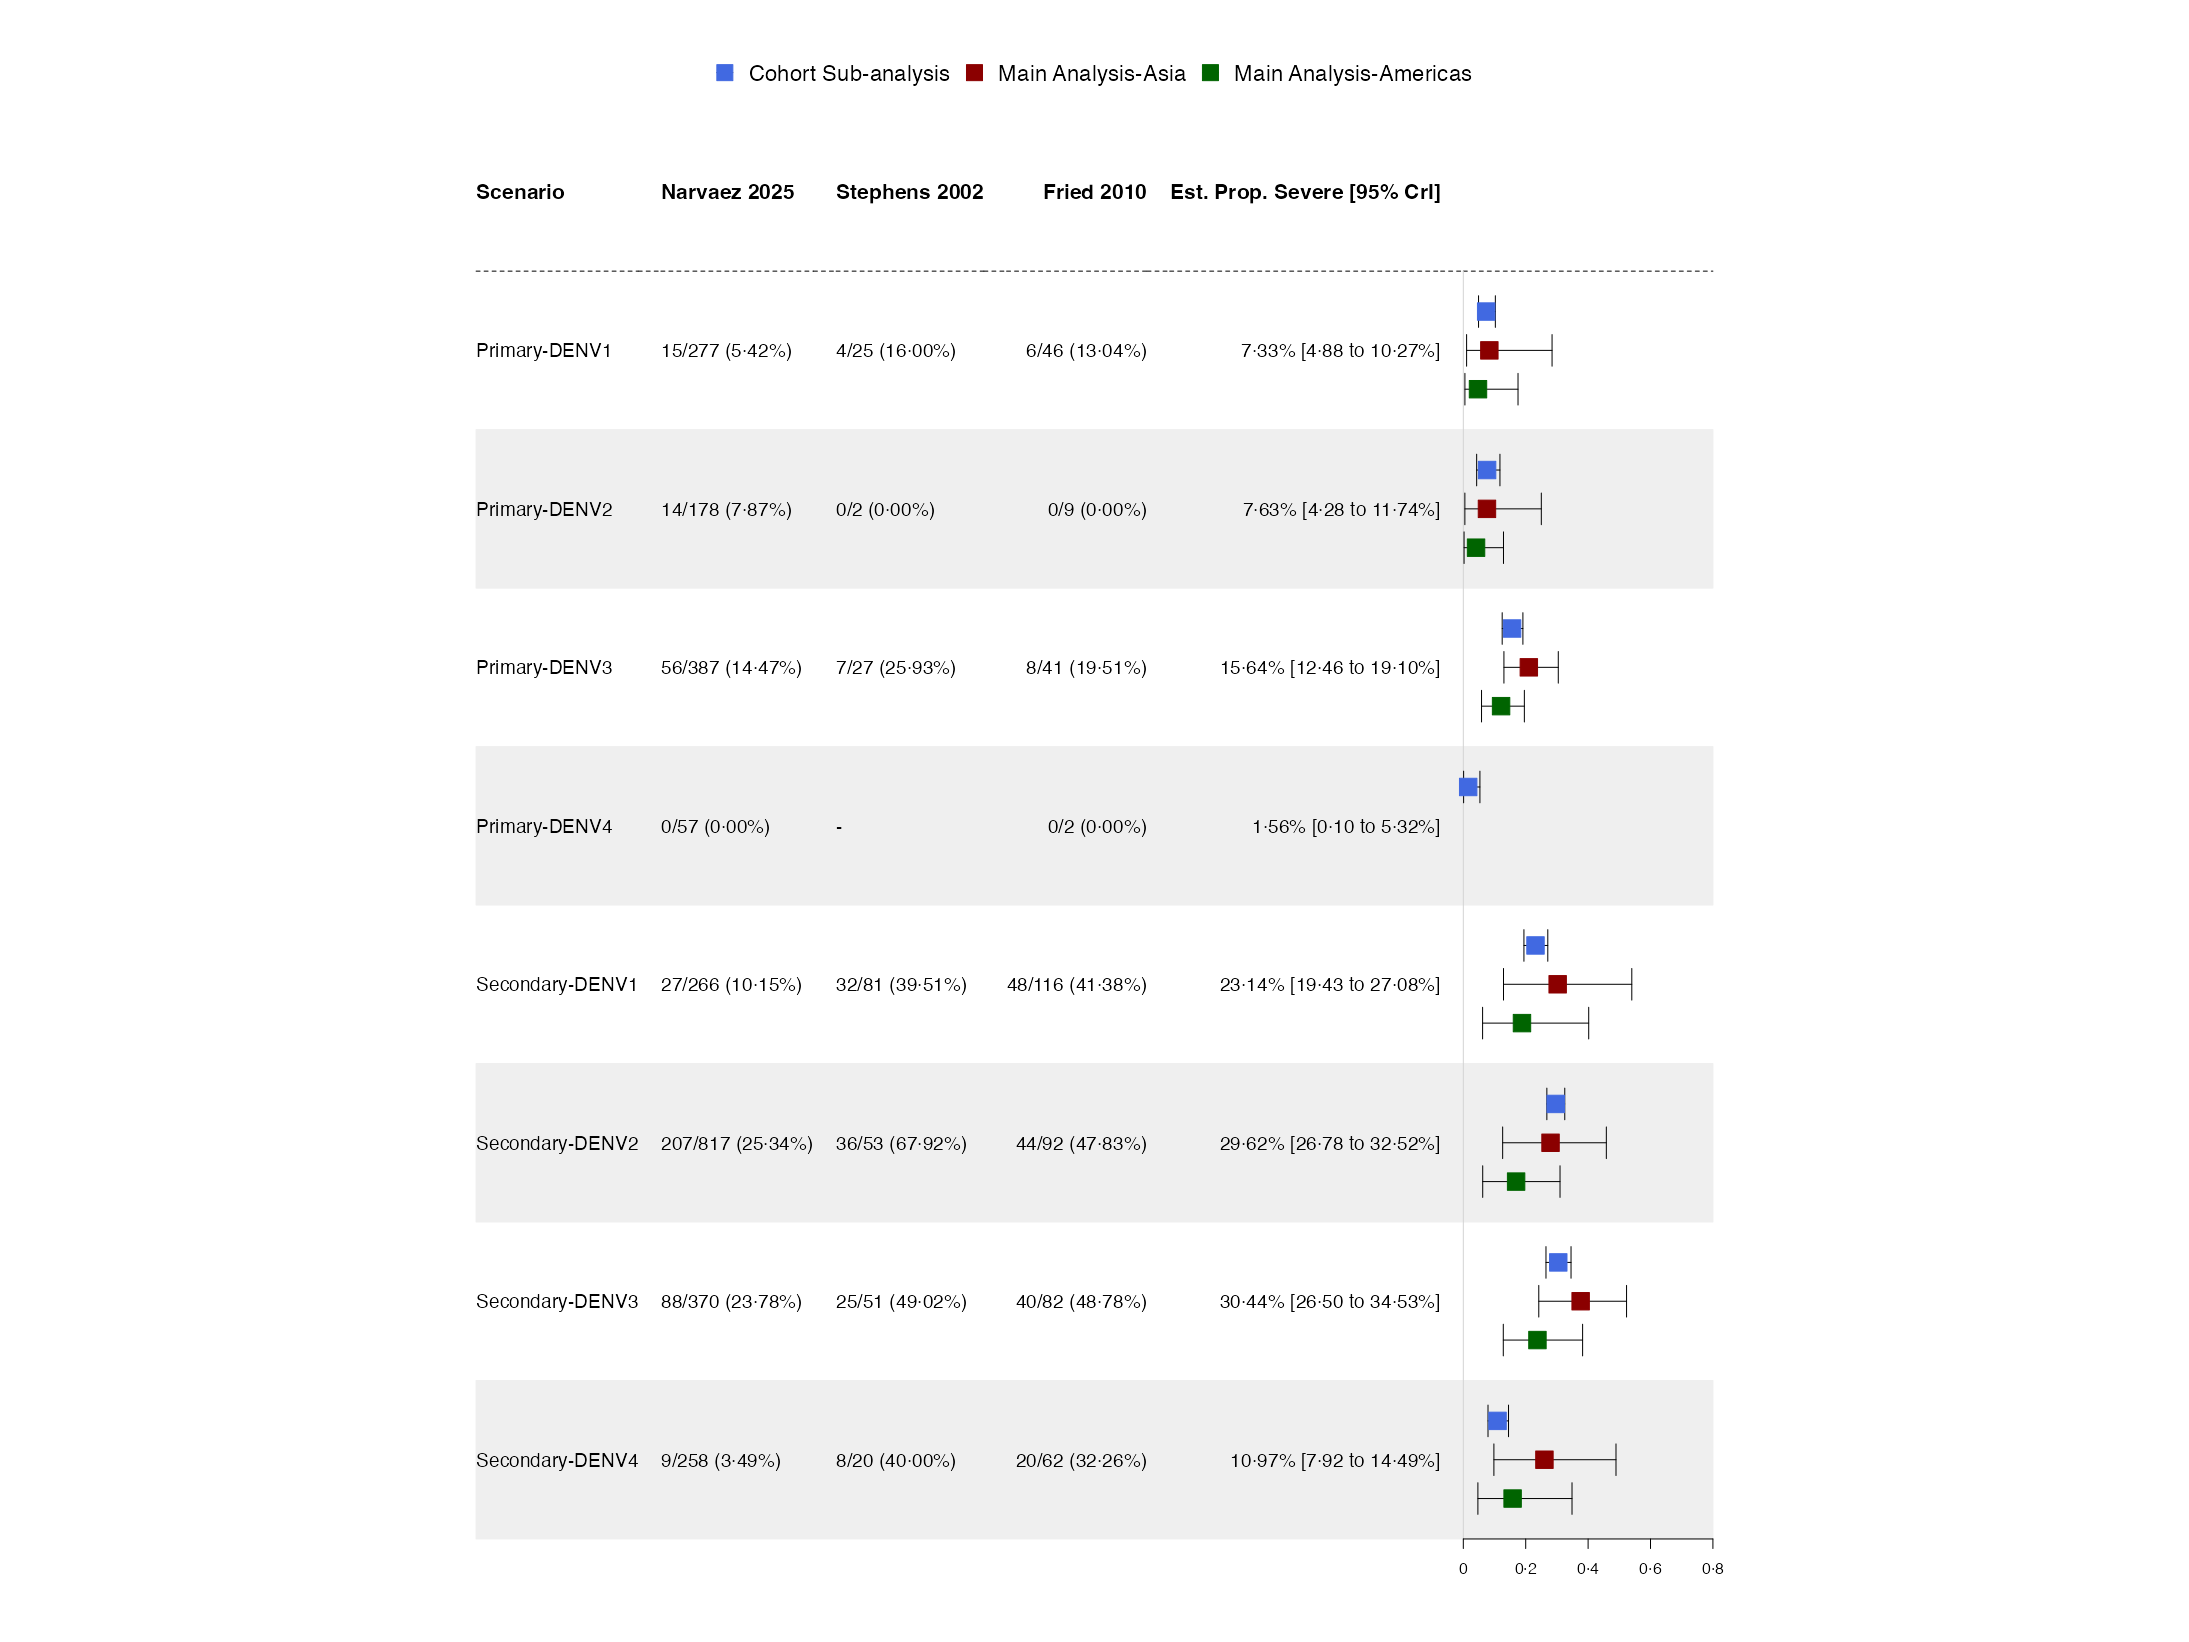

.ark.graphics.device 
                   2 

In [9]:
#Generate a forest plot to compare the main analysis with the cohort sub-analysis
options(repr.plot.width = 15, repr.plot.height = 10)
p_val_plot = p_vals %>% select(SeroPriorExp, `Narvaez 2025`, `Stephens 2002`, `Fried 2010`, DispVal) %>%
    forestplot(labeltext = c(SeroPriorExp, `Narvaez 2025`, `Stephens 2002`, `Fried 2010`, DispVal),
                mean = group_mean, lower = group_lower, upper = group_upper,
                xticks = seq(0, 0.8, by = 0.2), ci.vertices = TRUE, boxsize = 0.11, 
                align = c("l", "l", "l", "r", "r", "l"), graphwidth = unit(2.6, "in"),
                legend = c("Cohort Sub-analysis", "Main Analysis-Asia", "Main Analysis-Americas")
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = c("royalblue", "darkred", "darkgreen"), line = gpar(col = "black"), summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1), legend = gpar(cex = 1.4))) |>
    fp_add_header(
                    SeroPriorExp = "Scenario",
                    `Narvaez 2025` = "Narvaez 2025",
                    `Stephens 2002` = "Stephens 2002",
                    `Fried 2010` = "Fried 2010", 
                    DispVal = "Est. Prop. Severe [95% CrI]") |>
    fp_decorate_graph(graph.pos = 6) |>
    fp_set_zebra_style("#EFEFEF")
p_val_plot
if(save_output){
    #save_plot(p_val_plot, file.path(visuals_output_dir, paste0("PooledVals.png")), 15, 8, "in", 600)
    save_plot_all_formats(p_val_plot, visuals_output_dir, "PooledVals", 15, 8, "in", 600)
}

In [10]:
p_vals_all

    PointEst       Lower      Upper CharMatIndex    SeroPriorExp ColIndex
1 0·07326827 0·048830763 0·10268340            1   Primary-DENV1        1
2 0·07627105 0·042794476 0·11741605            2   Primary-DENV2        2
3 0·15637053 0·124606885 0·19099662            3   Primary-DENV3        3
4 0·01560337 0·001009957 0·05323816            4   Primary-DENV4        4
5 0·23139467 0·194285297 0·27078495            5 Secondary-DENV1        5
6 0·29615825 0·267781115 0·32518301           -1 Secondary-DENV2        6
7 0·30436218 0·264952052 0·34526787            6 Secondary-DENV3        7
8 0·10970826 0·079173327 0·14491347            7 Secondary-DENV4        8
                   DispVal     Narvaez 2025  Stephens 2002      Fried 2010
1   7.33% [4.88 to 10.27%]   15/277 (5.42%)  4/25 (16.00%)   6/46 (13.04%)
2   7.63% [4.28 to 11.74%]   14/178 (7.87%)    0/2 (0.00%)     0/9 (0.00%)
3 15.64% [12.46 to 19.10%]  56/387 (14.47%)  7/27 (25.93%)   8/41 (19.51%)
4    1.56% [0.10 to 5.32%]     0/5

## Checking for significant differences
Here, we then generate a figure, similar to the main analysis, to show if there are significant differences in severity between serotype-prior exposure combainations.

In [11]:
#char_mat_guide = char_mat_guide %>% mutate(CharMatIndex = ifelse(CharMatIndex == -1, 1, CharMatIndex + 1))
char_mat_guide = model_input$char_mat_guide
sero_prior_mat = summary(fit_model, pars = "sero_prior_or_ratios")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>%
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>%
                mutate(Name = rownames(.)) %>%
                separate(Name, sep = "\\[|,|\\]", into = c(NA, "ROW", "COL", NA)) %>% 
                mutate(ROW = as.numeric(ROW), COL = as.numeric(COL)) %>%
                filter(COL > ROW) %>% 
                left_join(char_mat_guide, by = c("ROW" = "CharMatIndex")) %>% #Join the indices based on the input char_mat_guide
                rename(RowScenario = SeroPriorExp) %>% 
                left_join(char_mat_guide, by = c("COL" = "CharMatIndex")) %>%
                rename(ColScenario = SeroPriorExp) %>% 
                select(-c(ROW, COL)) %>% 
                rename(Numerator = RowScenario, Denominator = ColScenario)

log_sero_prior_mat  = summary(fit_model, pars = "log_sero_prior_or_ratios")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>%
                rename(LogPointEst = mean, LogLower = X2.5., LogUpper = X97.5.) %>% mutate(Name = rownames(.)) %>%
                separate(Name, sep = "\\[|,|\\]", into = c(NA, "ROW", "COL", NA)) %>% 
                mutate(ROW = as.numeric(ROW), COL = as.numeric(COL)) %>%
                filter(COL > ROW) %>%
                select(-c(ROW, COL))
sero_prior_mat = cbind(sero_prior_mat, log_sero_prior_mat)

In [12]:
sero_prior_mat

                                 PointEst       Lower       Upper
log_sero_prior_or_ratios[1,2]  1·03066884 0·504959348   1·9448475
log_sero_prior_or_ratios[1,3]  0·43391948 0·262392734   0·6722884
log_sero_prior_or_ratios[1,4] 14·94268829 1·308731656  80·3177395
log_sero_prior_or_ratios[1,5]  0·26588936 0·161902223   0·4031477
log_sero_prior_or_ratios[1,6]  0·18240353 0·113162445   0·2730586
log_sero_prior_or_ratios[1,7]  0·66101996 0·375902983   1·0670549
log_sero_prior_or_ratios[2,3]  0·45423723 0·232652643   0·7679962
log_sero_prior_or_ratios[2,4] 15·64049055 1·291130199  83·4097772
log_sero_prior_or_ratios[2,5]  0·27837929 0·144091916   0·4622948
log_sero_prior_or_ratios[2,6]  0·19105021 0·100035387   0·3167633
log_sero_prior_or_ratios[2,7]  0·69221216 0·338078120   1·2177133
log_sero_prior_or_ratios[3,4] 35·05453387 3·178996085 183·3840251
log_sero_prior_or_ratios[3,5]  0·62284408 0·442819800   0·8531964
log_sero_prior_or_ratios[3,6]  0·42758403 0·307020505   0·5788322
log_sero_p

In [13]:
beta_or_guide = char_mat_guide %>% mutate(CharMatIndex = ifelse(CharMatIndex == -1, -1, CharMatIndex + 1)) %>% 
                rename(BetaOrIndex = CharMatIndex)
beta_or_est  = summary(fit_model, pars = "or_beta")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>% 
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% 
                mutate(Name = rownames(.)) %>% separate(Name, sep = "\\[|\\]", into = c(NA, "BetaOrIndex", NA)) %>%
                mutate(BetaOrIndex = as.integer(BetaOrIndex)) %>%  
                left_join(beta_or_guide, by = "BetaOrIndex") %>%
                filter(!is.na(SeroPriorExp)) %>%
                rename(Numerator = SeroPriorExp) %>% 
                mutate(Denominator = model_input$ref_serotype_exposure) %>% select(-BetaOrIndex)

In [14]:
log_beta_or_est = summary(fit_model, pars = c("log_or_beta"))$summary %>% data.frame %>% select(mean, X2.5., X97.5.) %>% 
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.)  %>% rename(LogPointEst = PointEst, LogLower = Lower, LogUpper = Upper) 
log_beta_or_est = log_beta_or_est[-1,]
beta_or_est = cbind(beta_or_est, log_beta_or_est)
beta_or_est

                 PointEst       Lower     Upper       Numerator     Denominator
log_or_beta[2] 0·18911607 0·119294087 0·2776989   Primary-DENV1 Secondary-DENV2
log_or_beta[3] 0·19797282 0·105202867 0·3213752   Primary-DENV2 Secondary-DENV2
log_or_beta[4] 0·44313359 0·328791387 0·5821414   Primary-DENV3 Secondary-DENV2
log_or_beta[5] 0·03831687 0·002428145 0·1345597   Primary-DENV4 Secondary-DENV2
log_or_beta[6] 0·71997782 0·552912718 0·9185607 Secondary-DENV1 Secondary-DENV2
log_or_beta[7] 1·04646835 0·817183992 1·3106385 Secondary-DENV3 Secondary-DENV2
log_or_beta[8] 0·29480004 0·199720155 0·4140866 Secondary-DENV4 Secondary-DENV2
               LogPointEst   LogLower    LogUpper
log_or_beta[2] -1·68860751 -2·1261635 -1·28121772
log_or_beta[3] -1·65887678 -2·2518647 -1·13514605
log_or_beta[4] -0·82448415 -1·1123318 -0·54104186
log_or_beta[5] -3·70461818 -6·0206278 -2·00574750
log_or_beta[6] -0·33700668 -0·5925551 -0·08494724
log_or_beta[7]  0·03822491 -0·2018910  0·27051439
log_or_bet

In [15]:
or_vis_df = rbind(sero_prior_mat, beta_or_est) %>% 
                    mutate(Significance = ifelse(((Lower > 1) | (Upper < 1)),"Significant", "Not Significant")) %>% #Check for significant OR
                    arrange(desc(Significance), desc(PointEst)) %>% mutate(DispVal = sprintf("%.2f [%.2f to %.2f]", PointEst, Lower, Upper)) %>% 
                    mutate(LogDispVal = sprintf("%.2f [%.2f to %.2f]", LogPointEst, LogLower, LogUpper)) %>% 
                    mutate(DispVal = str_replace_all(DispVal, "\\.", "·"), LogDispVal = str_replace_all(LogDispVal, "\\.", "·"))
or_vis_df

                                 PointEst       Lower       Upper
log_sero_prior_or_ratios[3,4] 35·05453387 3·178996085 183·3840251
log_sero_prior_or_ratios[2,4] 15·64049055 1·291130199  83·4097772
log_sero_prior_or_ratios[1,4] 14·94268829 1·308731656  80·3177395
log_sero_prior_or_ratios[6,7]  3·65782010 2·443012272   5·3289909
log_sero_prior_or_ratios[5,7]  2·51634286 1·659108300   3·7246277
log_or_beta[6]                 0·71997782 0·552912718   0·9185607
log_sero_prior_or_ratios[5,6]  0·69448537 0·516140007   0·9149468
log_sero_prior_or_ratios[3,5]  0·62284408 0·442819800   0·8531964
log_sero_prior_or_ratios[2,3]  0·45423723 0·232652643   0·7679962
log_or_beta[4]                 0·44313359 0·328791387   0·5821414
log_sero_prior_or_ratios[1,3]  0·43391948 0·262392734   0·6722884
log_sero_prior_or_ratios[3,6]  0·42758403 0·307020505   0·5788322
log_or_beta[8]                 0·29480004 0·199720155   0·4140866
log_sero_prior_or_ratios[2,5]  0·27837929 0·144091916   0·4622948
log_sero_p

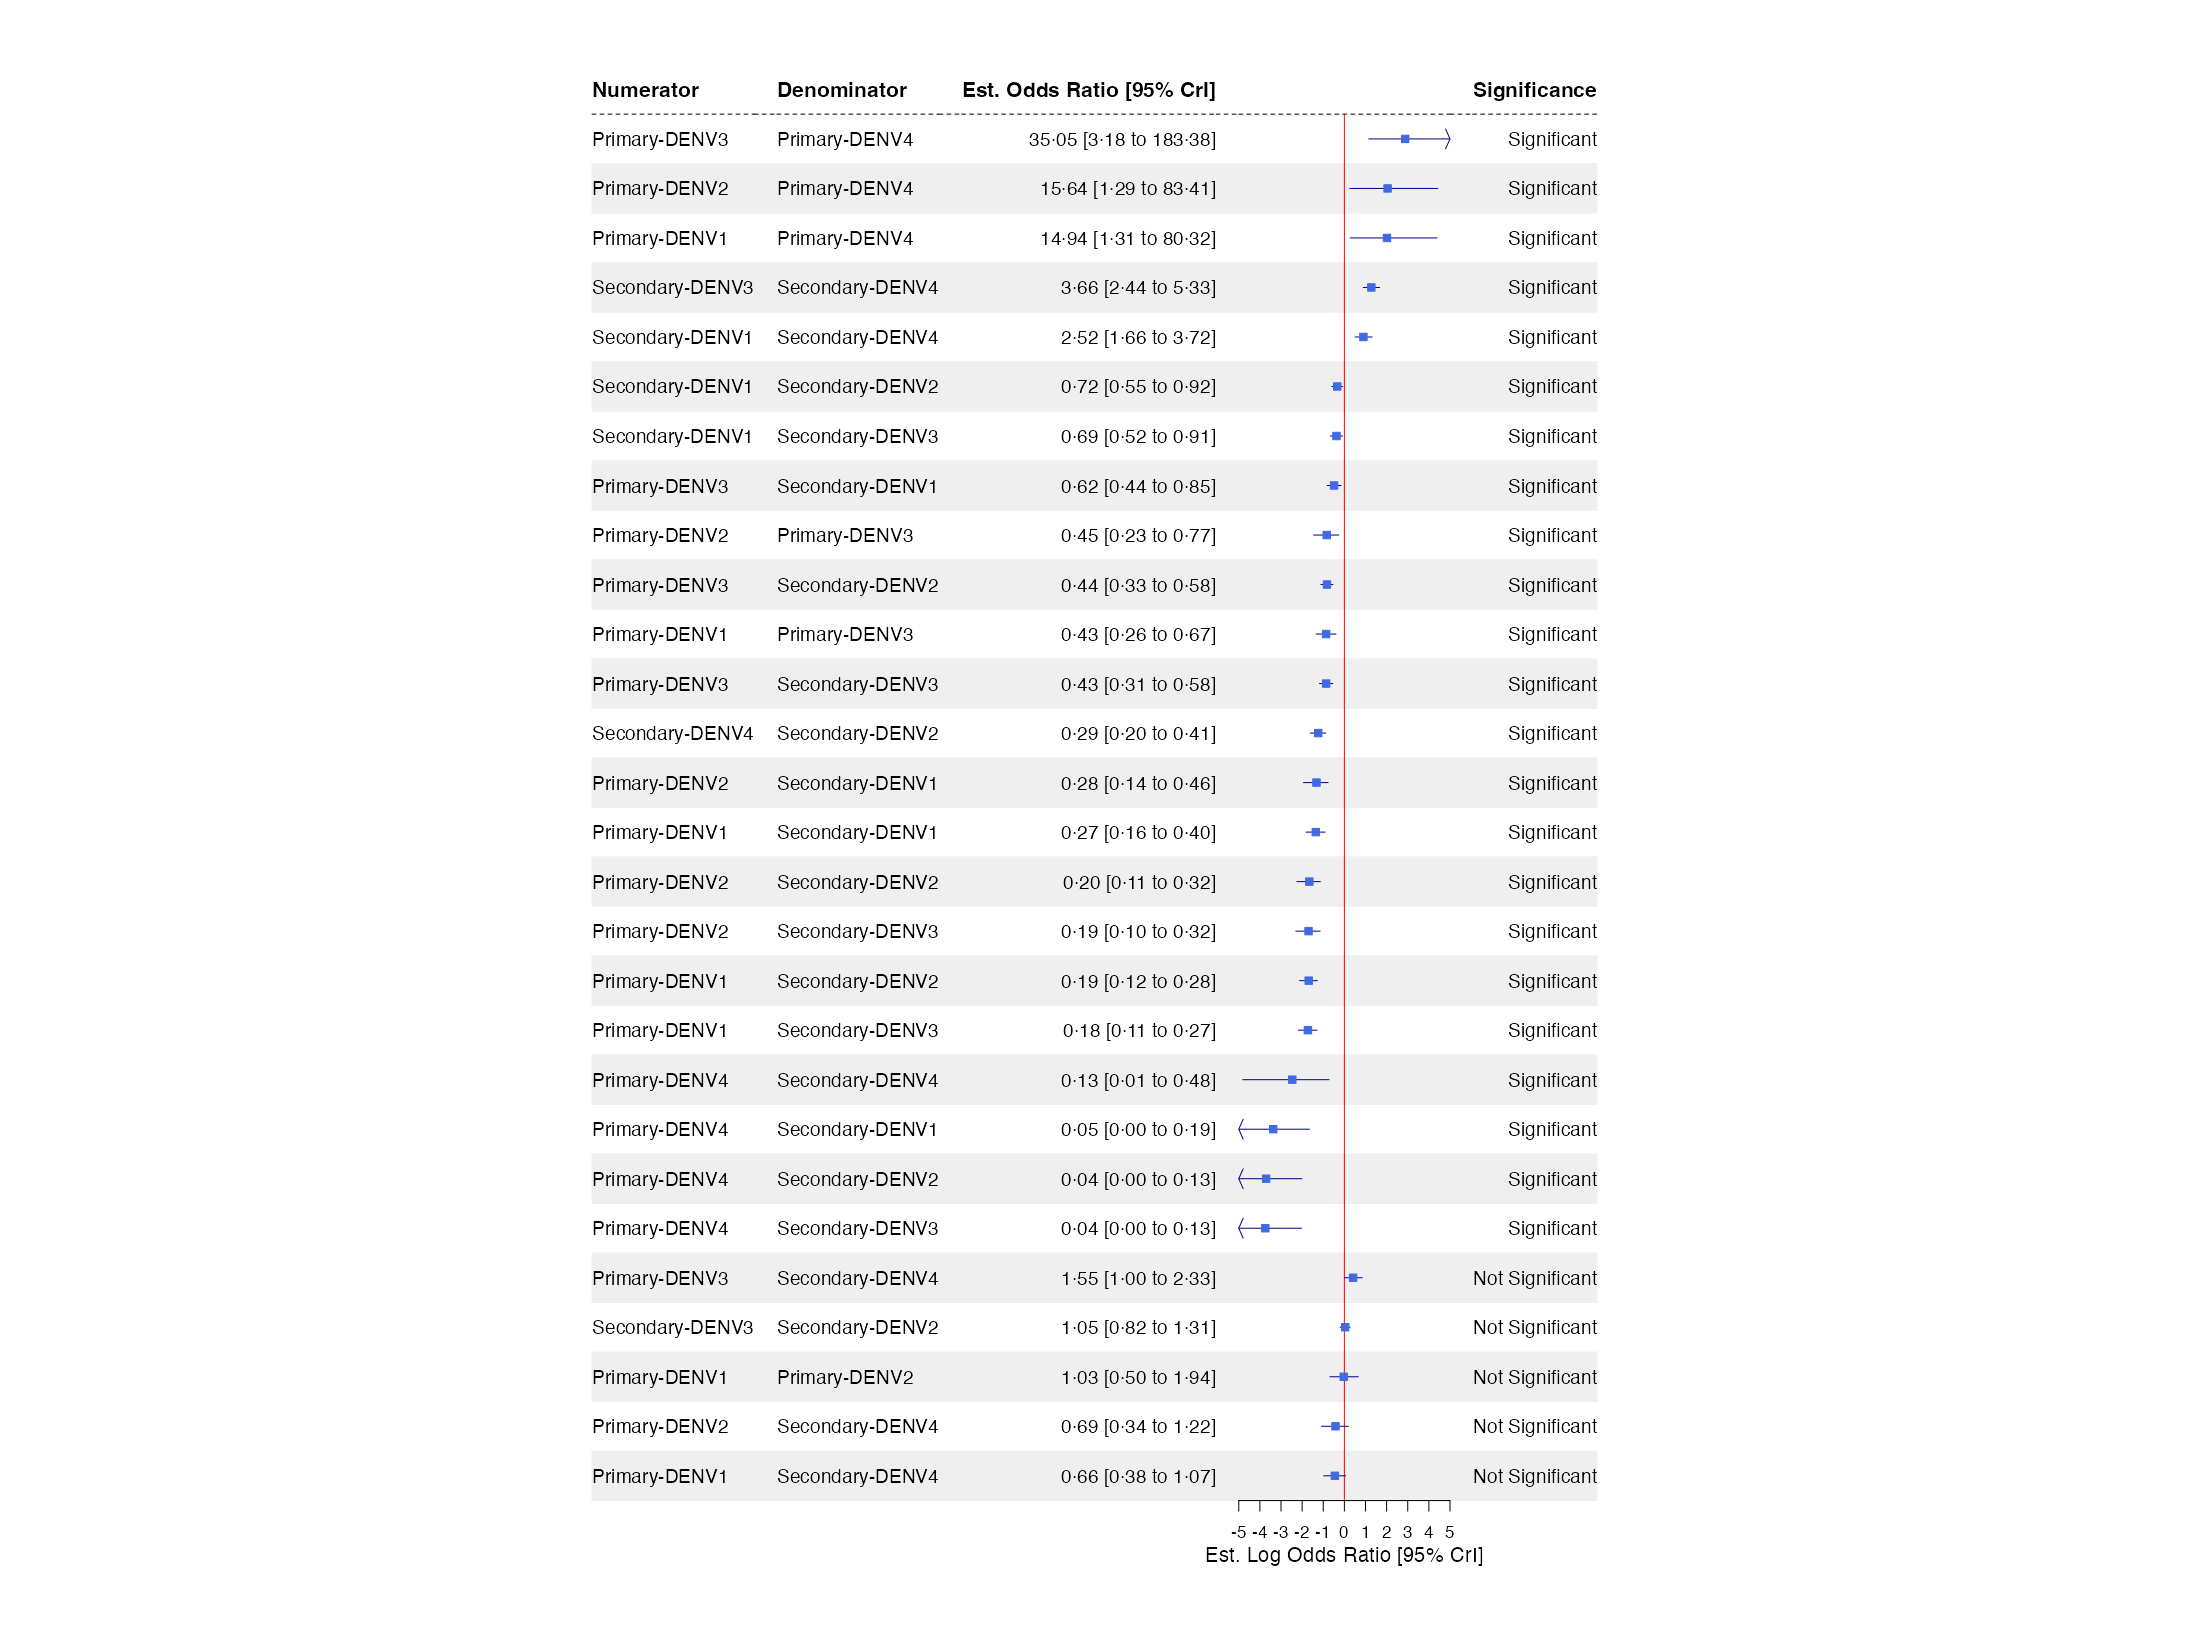

.ark.graphics.device 
                   2 

In [16]:
#Generate the plot
axis_lim = 5
options(repr.plot.width = 14, repr.plot.height = 16)
sero_prior_comp_plot = or_vis_df %>%
                forestplot(labeltext = c(Numerator, Denominator, DispVal, Significance), zero = 0,
                mean = LogPointEst, lower = LogLower, upper = LogUpper, clip = c(-axis_lim, axis_lim),
                xticks = seq(-axis_lim, axis_lim, by = as.integer(axis_lim/5)), boxsize = 0.15,
                align = c("l", "l", "r", "r"), graphwidth = unit(2.2, "in"), ci.vertices.height = 0.2, 
                           xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), zero = "red", summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1.1), xlab = gpar(cex = 1.3))) |>
    fp_add_header(
                    Numerator = "Numerator", 
                    Denominator = "Denominator", 
                    DispVal = "Est. Odds Ratio [95% CrI]",
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]",
                    Significance = "Significance"
    ) |> fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 4)
sero_prior_comp_plot
if(save_output){
    #save_plot(sero_prior_comp_plot, file.path(visuals_output_dir, paste0("OR_Ratios.png")), 14, 16, "in", 600)
    save_plot_all_formats(sero_prior_comp_plot, visuals_output_dir, "OR_Ratios", 14, 16, "in", 600)
}